In [68]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

## DATA LOADING & CLEANING

In [69]:
def load_logs(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return pd.json_normalize(data)

baseline_df = load_logs('data/history/baseline_architecture_log.json')
spear_df = load_logs('data/history/spear_architecture_log.json')
df = pd.concat([baseline_df, spear_df], ignore_index=True)


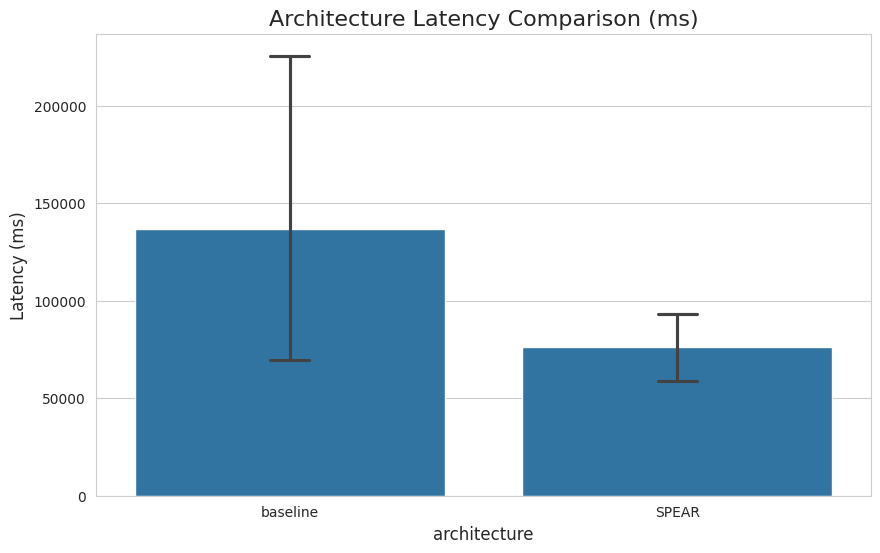

In [70]:
plt.figure(figsize=(10, 6))
sns.barplot(x='architecture', y='latency_ms', data=df, capsize=.1)
plt.title('Architecture Latency Comparison (ms)')
plt.ylabel('Latency (ms)')
plt.show()

## EVALUATION 1: OVERALL ARCHITECTURE PERFORMANCE

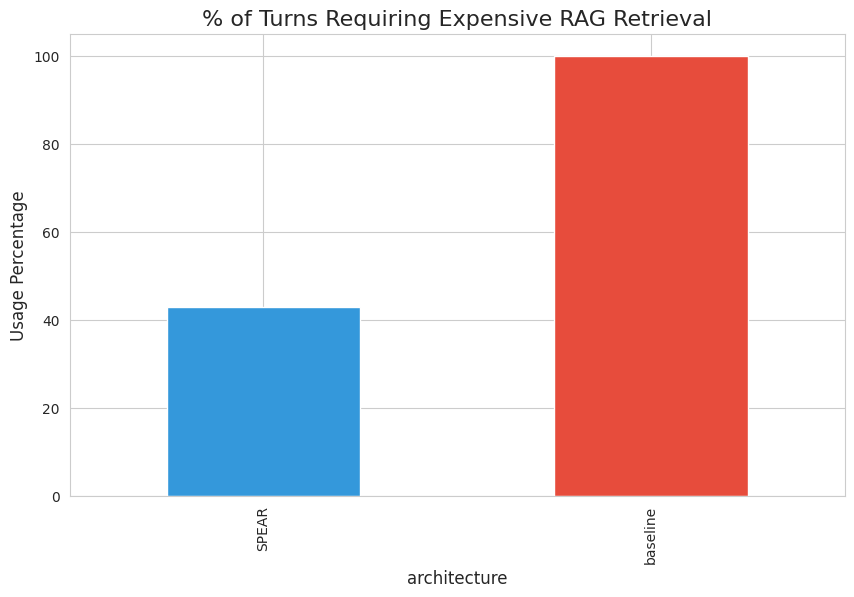

In [71]:
plt.figure(figsize=(10, 6))
rag_usage = df.groupby('architecture')['retrieval_types.rag_vector'].mean() * 100
rag_usage.plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('% of Turns Requiring Expensive RAG Retrieval')
plt.ylabel('Usage Percentage')
plt.show()

## EVALUATION 2: SEMANTIC ROUTER EFFICIENCY (GRAPH ONLY)

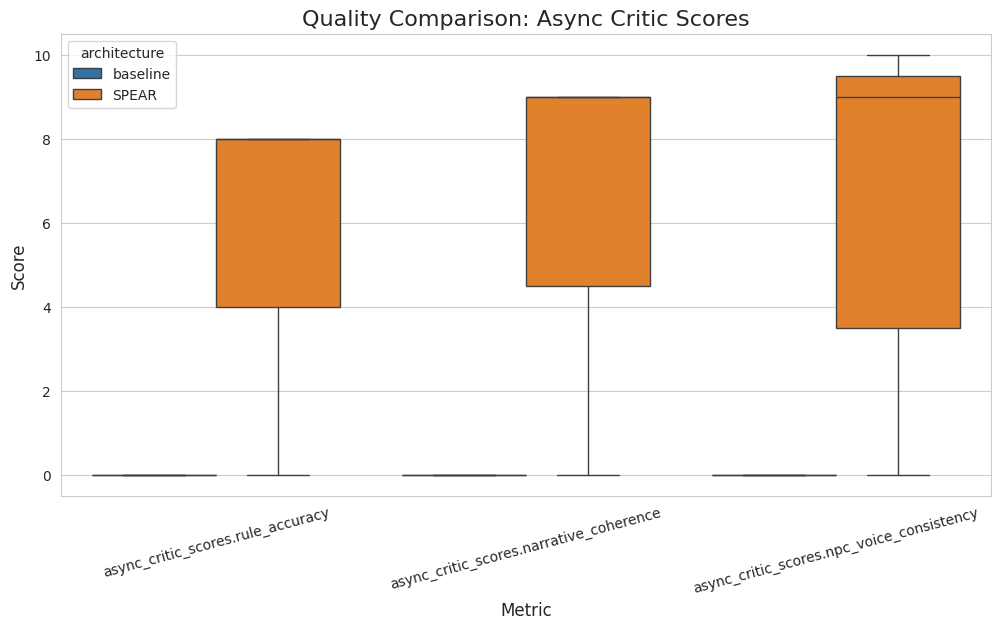

In [72]:
critic_cols = [
    'async_critic_scores.rule_accuracy', 
    'async_critic_scores.narrative_coherence', 
    'async_critic_scores.npc_voice_consistency'
]

# Standardize scores (Handling 0s or NaNs)
melted_df = df.melt(id_vars=['architecture'], value_vars=critic_cols, var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.boxplot(x='Metric', y='Score', hue='architecture', data=melted_df)
plt.title('Quality Comparison: Async Critic Scores')
plt.xticks(rotation=15)
plt.show()

## EVALUATION 3: THE COST OF REFLECTION (GRAPH ONLY)

In [73]:
hallucination_rate = spear_df['routing_hallucination'].mean() * 100
print(f"SPEAR Routing Hallucination Rate: {hallucination_rate:.2f}%")

SPEAR Routing Hallucination Rate: 0.00%


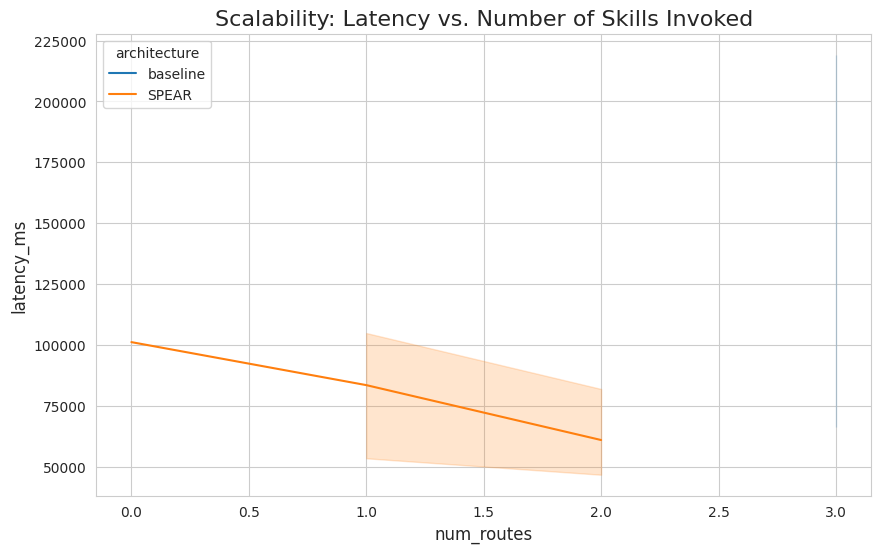

In [74]:
# Create a count of how many routes were fired per turn
df['num_routes'] = df['routes_fired.rules_logic'].astype(int) + \
                   df['routes_fired.npc_lore'].astype(int) + \
                   df['routes_fired.world_exploration'].astype(int)

plt.figure(figsize=(10, 6))
sns.lineplot(x='num_routes', y='latency_ms', hue='architecture', data=df)
plt.title('Scalability: Latency vs. Number of Skills Invoked')
plt.show()

In [75]:
# 1. Standardize the columns
df['num_routes'] = df['routes_fired.rules_logic'].astype(int) + \
                   df['routes_fired.npc_lore'].astype(int) + \
                   df['routes_fired.world_exploration'].astype(int)

# 2. Corrected Sparsity Calculation
spear_mask = df['architecture'] == 'SPEAR'
spear_data = df[spear_mask]

if len(spear_data) > 0:
    total_possible_slots = len(spear_data) * 3
    total_actual_slots = spear_data['num_routes'].sum()
    sparsity_val = (1 - (total_actual_slots / total_possible_slots)) * 100

    # THE FIX: Added the 'f' prefix to the string below
    print(f"SPEAR Skill Sparsity: {sparsity_val:.2f}%")
    print(f"Interpretation: SPEAR successfully avoided loading unneeded skills in {sparsity_val:.2f}% of potential cases.")
else:
    print("Error: No SPEAR logs found in the dataframe.")

SPEAR Skill Sparsity: 57.14%
Interpretation: SPEAR successfully avoided loading unneeded skills in 57.14% of potential cases.


SPEAR Skill Sparsity: 57.14%
Interpretation: SPEAR avoided loading unneeded skills in 57.14% of potential cases.


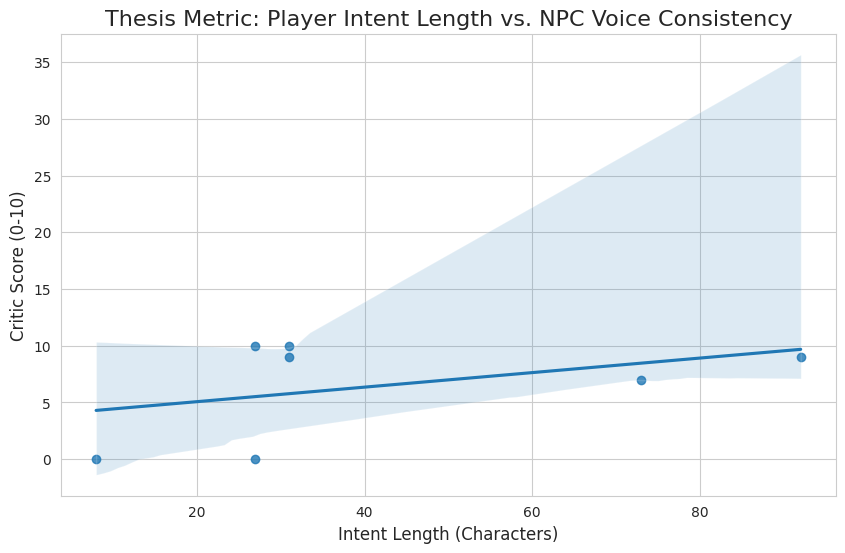

In [76]:
# Calculate the new metrics on the combined dataframe first
df['num_routes'] = df['routes_fired.rules_logic'].astype(int) + \
                   df['routes_fired.npc_lore'].astype(int) + \
                   df['routes_fired.world_exploration'].astype(int)

df['intent_length'] = df['player_intent'].str.len()

# Sparsity Calculation
spear_mask = df['architecture'] == 'SPEAR'
total_possible_slots = len(df[spear_mask]) * 3
total_actual_slots = df[spear_mask]['num_routes'].sum()
sparsity_val = (1 - (total_actual_slots / total_possible_slots)) * 100

print(f"SPEAR Skill Sparsity: {sparsity_val:.2f}%")
print(f"Interpretation: SPEAR avoided loading unneeded skills in {sparsity_val:.2f}% of potential cases.")

# Plot Narrative Depth (SPEAR Only)
plt.figure(figsize=(10, 6))
# Filter directly inside the plot call to avoid KeyError
sns.regplot(
    x='intent_length', 
    y='async_critic_scores.npc_voice_consistency', 
    data=df[df['architecture'] == 'SPEAR']
)
plt.title('Thesis Metric: Player Intent Length vs. NPC Voice Consistency')
plt.xlabel('Intent Length (Characters)')
plt.ylabel('Critic Score (0-10)')
plt.show()